In [2]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# 加载UNSW-NB15数据集
def load_unsw_nb15(data_path):
    # 读取CSV文件
    df = pd.read_csv(data_path)
    
    # 数据清洗
    df = df.dropna()  # 移除缺失值
    df = df.drop_duplicates()  # 移除重复记录
    
    # 特征选择（根据需要调整）
    numeric_features = [
        'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 
        'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
        'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
        'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
        'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
        'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
        'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
        'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports'
    ]
    
    categorical_features = [
        'proto', 'service', 'state'
    ]
    
    # 处理数值特征
    scaler = StandardScaler()
    X_num = scaler.fit_transform(df[numeric_features])
    
    # 处理分类特征
    X_cat = pd.get_dummies(df[categorical_features])
    
    # 合并特征
    X = np.hstack([X_num, X_cat.values])
    
    # 处理标签
    le = LabelEncoder()
    y = le.fit_transform(df['label'])  # 0=正常，1=攻击
    
    # 处理攻击类别
    attack_cat = le.fit_transform(df['attack_cat'].fillna('Normal'))
    
    return X, y, attack_cat, df

# 构建图数据
def build_graph_data(X, y, attack_cat, df, k_neighbors=5):
    # 使用KNN算法构建图连接
    from sklearn.neighbors import kneighbors_graph
    adj_matrix = kneighbors_graph(X, k_neighbors, mode='distance', include_self=False)
    
    # 转换为稀疏矩阵格式
    edge_index = []
    edge_weight = []
    
    for i, j in zip(*adj_matrix.nonzero()):
        edge_index.append([i, j])
        edge_weight.append(adj_matrix[i, j])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)
    
    # 节点特征和标签
    x = torch.tensor(X, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.long)
    attack_cat = torch.tensor(attack_cat, dtype=torch.long)
    
    # 创建图数据对象
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y, attack_cat=attack_cat)
    
    # 划分训练集、验证集和测试集
    indices = torch.arange(data.num_nodes)
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    train_idx, val_idx = train_test_split(train_idx, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2
    
    data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    
    data.train_mask[train_idx] = True
    data.val_mask[val_idx] = True
    data.test_mask[test_idx] = True
    
    return data

In [23]:
import scipy.linalg as la

class JordanMatrixDecomposition:
    def __init__(self, adj_matrix, n_components=100, solver='lobpcg', max_iter=30000, tol=1e-3, 
                 preprocess=True, use_pca_init=True, n_pca_components=200, postprocess=True):
        """初始化约旦矩阵分解类，新增参数控制矩阵维度"""
        self.adj_matrix = adj_matrix
        self.n_components = n_components
        self.solver = solver
        self.max_iter = max_iter
        self.tol = tol
        self.preprocess = preprocess
        self.use_pca_init = use_pca_init
        self.n_pca_components = n_pca_components
        self.postprocess = postprocess
        
        # 计算约旦分解并确保矩阵维度正确
        self.jordan_form, self.trans_matrix = self._compute_jordan_form()
        self.eigenvalues = np.diag(self.jordan_form)
        
        # 验证矩阵维度（新增）
        if self.trans_matrix.shape[0] != self.trans_matrix.shape[1]:
            print(f"警告：特征向量矩阵形状为 {self.trans_matrix.shape}，非方阵，将进行维度截断")
            min_dim = min(self.trans_matrix.shape)
            self.trans_matrix = self.trans_matrix[:min_dim, :min_dim]
            self.jordan_form = self.jordan_form[:min_dim, :min_dim]
            self.eigenvalues = self.eigenvalues[:min_dim]
    
    def _compute_jordan_form(self):
        """优化特征值分解过程，确保返回方阵"""
        try:
            # 原有逻辑...（省略重复代码）
            
            # 关键修改：确保特征向量矩阵为方阵
            if self.trans_matrix.shape[0] != self.trans_matrix.shape[1]:
                # 若特征向量矩阵非方阵，取前k行k列（k为较小维度）
                k = min(self.trans_matrix.shape)
                eigenvalues = eigenvalues[:k]
                eigenvectors = eigenvectors[:k, :k]  # 取前k个特征向量的前k维
            
            jordan_form = np.diag(eigenvalues)
            trans_matrix = eigenvectors
            
            return jordan_form, trans_matrix
        except Exception as e:
            # 原有错误处理...（省略）
            raise ValueError(f"特征值分解失败: {e}")

    def get_propagation_matrix(self, t=1):
        """计算传播矩阵，新增维度检查"""
        # 验证矩阵是否为方阵
        if self.trans_matrix.shape[0] != self.trans_matrix.shape[1]:
            raise ValueError(f"特征向量矩阵形状为 {self.trans_matrix.shape}，必须为方阵")
        
        if self.jordan_form.shape[0] != self.jordan_form.shape[1]:
            raise ValueError(f"约旦矩阵形状为 {self.jordan_form.shape}，必须为方阵")
        
        # 计算约旦矩阵的幂
        jordan_power = np.linalg.matrix_power(self.jordan_form, t)
         # 关键修改：确保矩阵乘法维度匹配
        try:
            propagation_matrix = self.trans_matrix @ jordan_power @ np.linalg.inv(self.trans_matrix)
        except np.linalg.LinAlgError as e:
            print(f"矩阵求逆失败: {e}")
            print(f"矩阵形状: trans_matrix={self.trans_matrix.shape}, jordan_power={jordan_power.shape}")
            # 回退方案：使用伪逆
            propagation_matrix = self.trans_matrix @ jordan_power @ np.linalg.pinv(self.trans_matrix)
        
        return propagation_matrix
    
    def predict_infection(self, initial_state, t=1):
        """
        预测t步后的感染状态
        
        参数:
            initial_state: 初始感染状态向量 (numpy array)
            t: 时间步数
        
        返回:
            预测的感染状态向量 (numpy array)
        """
        propagation_matrix = self.get_propagation_matrix(t)
        return propagation_matrix @ initial_state

In [4]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool

class GNNModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.5, gnn_type='GCN'):
        super().__init__()
        self.dropout = dropout
        self.layers = torch.nn.ModuleList()
        
        # 输入层
        if gnn_type == 'GCN':
            self.layers.append(GCNConv(input_dim, hidden_dim))
        elif gnn_type == 'GAT':
            self.layers.append(GATConv(input_dim, hidden_dim))
        elif gnn_type == 'GraphSAGE':
            self.layers.append(SAGEConv(input_dim, hidden_dim))
        
        # 隐藏层
        for _ in range(num_layers - 2):
            if gnn_type == 'GCN':
                self.layers.append(GCNConv(hidden_dim, hidden_dim))
            elif gnn_type == 'GAT':
                self.layers.append(GATConv(hidden_dim, hidden_dim))
            elif gnn_type == 'GraphSAGE':
                self.layers.append(SAGEConv(hidden_dim, hidden_dim))
        
        # 输出层
        self.layers.append(GCNConv(hidden_dim, output_dim))
    
    def forward(self, x, edge_index, edge_weight=None):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x, edge_index, edge_weight)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.layers[-1](x, edge_index, edge_weight)
        return x

In [5]:
class CollaborativeAnalysisModel(torch.nn.Module):
    def __init__(self, gnn_model, jordan_matrix, feature_dim, hidden_dim, num_classes):
        super().__init__()
        self.gnn = gnn_model
        self.jordan_matrix = jordan_matrix
        
        # 特征融合层
        self.fusion = torch.nn.Sequential(
            torch.nn.Linear(feature_dim + len(jordan_matrix.eigenvalues), hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5)
        )
        
        # 分类器
        self.classifier = torch.nn.Linear(hidden_dim, num_classes)
        
        # 关键节点预测器
        self.key_node_predictor = torch.nn.Linear(hidden_dim, 1)
    
    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.edge_attr
        
        # GNN特征提取
        gnn_features = self.gnn(x, edge_index, edge_weight)
        
        # 约旦矩阵特征
        jordan_features = torch.tensor(
            self.jordan_matrix.eigenvalues, 
            dtype=torch.float, 
            device=x.device
        ).expand(gnn_features.size(0), -1)
        
        # 特征融合
        combined_features = torch.cat([gnn_features, jordan_features], dim=1)
        fused_features = self.fusion(combined_features)
        
        # 分类预测
        class_pred = self.classifier(fused_features)
        
        # 关键节点预测
        key_node_scores = self.key_node_predictor(fused_features).squeeze()
        
        return {
            'class_pred': class_pred,
            'key_node_scores': key_node_scores,
            'gnn_features': gnn_features,
            'jordan_features': jordan_features
        }

In [ ]:
# 训练函数
def train(model, data, optimizer, criterion, device):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(data)
    loss = criterion(outputs['class_pred'][data.train_mask], data.y[data.train_mask])
    
    loss.backward()
    optimizer.step()
    
    return loss.item()

# 评估函数
def evaluate(model, data, device):
    model.eval()
    
    outputs = model(data)
    pred = outputs['class_pred'].argmax(dim=1)  # 使用最大概率作为预测结果
    
    # 计算准确率
    train_acc = pred[data.train_mask].eq(data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
    val_acc = pred[data.val_mask].eq(data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
    test_acc = pred[data.test_mask].eq(data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
    
    # 计算RPA（相对传播准确率）
    from sklearn.metrics import precision_recall_fscore_support
    
    # 假设我们使用关键节点预测分数
    key_nodes = outputs['key_node_scores'] > 0.5
    
    # 计算RPA（需要真实的传播信息）
    # 这里简化处理，使用标签作为代理
    rpa = precision_recall_fscore_support(
        data.y[data.test_mask], 
        pred[data.test_mask], 
        average='macro'
    )[2]  # F1分数作为RPA的近似
    
    return {
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'rpa': rpa
    }

# 主函数
def main():
    # 加载数据
    X, y, attack_cat, df = load_unsw_nb15(r'D:\code\github\kaggle_data\mrwellsdavid\unsw-nb15\versions\1\UNSW_NB15_training-set.csv')
    
    # 构建图数据
    data = build_graph_data(X, y, attack_cat, df)
    
    # 计算约旦矩阵
    adj_matrix = data.edge_index.cpu().numpy().T
    jordan_decomp = JordanMatrixDecomposition(adj_matrix)
    
    # 初始化模型
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data = data.to(device)
    
    gnn = GNNModel(
        input_dim=data.x.size(1),
        hidden_dim=64,
        output_dim=32,
        num_layers=3
    ).to(device)
    
    model = CollaborativeAnalysisModel(
        gnn_model=gnn,
        jordan_matrix=jordan_decomp,
        feature_dim=32,
        hidden_dim=64,
        num_classes=2  # 二分类：正常/攻击
    ).to(device)
    
    # 优化器和损失函数
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()
    
    # 训练循环
    best_val_acc = 0
    patience = 10
    counter = 0
    
    for epoch in range(1, 201):
        loss = train(model, data, optimizer, criterion, device)
        metrics = evaluate(model, data, device)
        
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {metrics["train_acc"]:.4f}, '
              f'Val: {metrics["val_acc"]:.4f}, Test: {metrics["test_acc"]:.4f}, RPA: {metrics["rpa"]:.4f}')
        
        # 早停策略
        if metrics['val_acc'] > best_val_acc:
            best_val_acc = metrics['val_acc']
            torch.save(model.state_dict(), 'best_model.pt')
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print('Early stopping!')
                break
    
    # 加载最佳模型并评估
    model.load_state_dict(torch.load('best_model.pt'))
    final_metrics = evaluate(model, data, device)
    print(f'Final Test Acc: {final_metrics["test_acc"]:.4f}, RPA: {final_metrics["rpa"]:.4f}')
    
    # 关键节点分析
    model.eval()
    outputs = model(data)
    key_node_scores = outputs['key_node_scores'].detach().cpu().numpy()
    
    # 获取Top-K关键节点
    k = 10
    top_k_nodes = np.argsort(-key_node_scores)[:k]
    
    print(f'Top {k} critical nodes: {top_k_nodes}')
    print(f'Their scores: {key_node_scores[top_k_nodes]}')
    
    # 威胁传播预测（简化示例）
    initial_state = np.zeros(data.num_nodes)
    initial_state[top_k_nodes[0]] = 1  # 假设第一个关键节点被感染
    
    # 使用约旦矩阵预测传播
    propagation_steps = 5
    infection_state = jordan_decomp.predict_infection(initial_state, t=propagation_steps)
    
    # 找出可能被感染的前10个节点
    potential_victims = np.argsort(-infection_state)[:10]
    print(f'Potential victims after {propagation_steps} steps: {potential_victims}')
    print(f'Infection probabilities: {infection_state[potential_victims]}')

if __name__ == '__main__':
    main()

: 

In [24]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh, lobpcg
import matplotlib.pyplot as plt
from scipy.sparse import csgraph

# 加载UNSW-NB15数据集
def load_unsw_nb15(data_path):
    # 读取CSV文件
    df = pd.read_csv(data_path)
    print(f"原始数据集大小: {df.shape}")
    
    # 数据清洗
    df = df.dropna()  # 移除缺失值
    df = df.drop_duplicates()  # 移除重复记录
    print(f"清洗后数据集大小: {df.shape}")
    
    # 特征选择（根据需要调整）
    numeric_features = [
        'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 
        'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
        'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
        'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean',
        'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src',
        'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
        'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
        'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports'
    ]
    
    categorical_features = [
        'proto', 'service', 'state'
    ]
    
    # 处理数值特征
    scaler = StandardScaler()
    X_num = scaler.fit_transform(df[numeric_features])
    
    # 处理分类特征
    X_cat = pd.get_dummies(df[categorical_features])
    
    # 合并特征
    X = np.hstack([X_num, X_cat.values])
    
    # 处理标签
    le = LabelEncoder()
    y = le.fit_transform(df['label'])  # 0=正常，1=攻击
    
    # 处理攻击类别
    attack_cat = le.fit_transform(df['attack_cat'].fillna('Normal'))
    
    return X, y, attack_cat, df

# 构建图数据
def build_graph_data(X, y, attack_cat, df, k_neighbors=3):
    # 使用KNN算法构建图连接
    from sklearn.neighbors import kneighbors_graph
    adj_matrix = kneighbors_graph(X, k_neighbors, mode='distance', include_self=False)
    
    # 转换为稀疏矩阵格式
    edge_index = []
    edge_weight = []
    
    for i, j in zip(*adj_matrix.nonzero()):
        edge_index.append([i, j])
        edge_weight.append(adj_matrix[i, j])
    
    # 对边权重进行归一化
    edge_weight = np.exp(-np.array(edge_weight))  # 使用高斯核
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weight, dtype=torch.float)
    
    # 节点特征和标签
    x = torch.tensor(X, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.long)
    attack_cat = torch.tensor(attack_cat, dtype=torch.long)
    
    # 创建图数据对象
    data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight, y=y, attack_cat=attack_cat)
    
    # 划分训练集、验证集和测试集
    indices = torch.arange(data.num_nodes)
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
    train_idx, val_idx = train_test_split(train_idx, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2
    
    data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    
    data.train_mask[train_idx] = True
    data.val_mask[val_idx] = True
    data.test_mask[test_idx] = True
    
    return data

class JordanMatrixDecomposition:
    def __init__(self, adj_matrix, n_components=100, solver='lobpcg', max_iter=30000, tol=1e-3, 
                 preprocess=True, use_pca_init=True, n_pca_components=200, postprocess=True):
        """初始化约旦矩阵分解类，新增参数控制矩阵维度"""
        self.adj_matrix = adj_matrix
        self.n_components = n_components
        self.solver = solver
        self.max_iter = max_iter
        self.tol = tol
        self.preprocess = preprocess
        self.use_pca_init = use_pca_init
        self.n_pca_components = n_pca_components
        self.postprocess = postprocess
        
        # 计算约旦分解并确保矩阵维度正确
        self.jordan_form, self.trans_matrix = self._compute_jordan_form()
        self.eigenvalues = np.diag(self.jordan_form)
        
        # 验证矩阵维度（新增）
        if self.trans_matrix.shape[0] != self.trans_matrix.shape[1]:
            print(f"警告：特征向量矩阵形状为 {self.trans_matrix.shape}，非方阵，将进行维度截断")
            min_dim = min(self.trans_matrix.shape)
            self.trans_matrix = self.trans_matrix[:min_dim, :min_dim]
            self.jordan_form = self.jordan_form[:min_dim, :min_dim]
            self.eigenvalues = self.eigenvalues[:min_dim]
    
    def _compute_jordan_form(self):
        """计算约旦标准型的近似"""
        try:
            matrix = self.adj_matrix.asfptype()  # 转换为浮点型稀疏矩阵
            
            # 矩阵预处理
            if self.preprocess:
                # 添加小的对角扰动以改善数值稳定性
                matrix = matrix + sp.eye(matrix.shape[0], format='csr') * 1e-10
                
                # 对称化矩阵
                matrix = 0.5 * (matrix + matrix.T)
                
                # 计算图拉普拉斯矩阵（如果需要）
                # matrix = csgraph.laplacian(matrix, normed=True)
            
            # 生成初始猜测向量
            if self.use_pca_init:
                # 使用PCA生成更有信息的初始向量
                print("使用PCA生成初始向量...")
                from sklearn.decomposition import TruncatedSVD
                svd = TruncatedSVD(n_components=min(self.n_pca_components, matrix.shape[0]-1))
                X = svd.fit_transform(matrix)
            else:
                # 随机初始化
                X = np.random.rand(matrix.shape[0], min(self.n_components, 50))
            
            # 计算特征值和特征向量
            if self.solver == 'arpack':
                # 使用ARPACK求解器
                eigenvalues, eigenvectors = eigsh(
                    matrix,
                    k=min(self.n_components, matrix.shape[0]-1),
                    which='LM',  # 计算最大的特征值
                    maxiter=self.max_iter,
                    tol=self.tol,
                    sigma=1e-10  # 避免零特征值问题
                )
            else:
                # 使用LOBPCG求解器
                # 创建预条件器（如果需要）
                M = None  # 可以在这里添加预条件器
                
                # 计算特征值和特征向量
                eigenvalues, eigenvectors = lobpcg(
                    matrix,
                    X,
                    M=M,
                    largest=True,
                    maxiter=self.max_iter,
                    tol=self.tol,
                    verbosityLevel=0  # 减少输出
                )
            
            # 构建约旦标准型（对角矩阵）
            jordan_form = np.diag(eigenvalues)
            trans_matrix = eigenvectors
            
            return jordan_form, trans_matrix
        except Exception as e:
            print(f"特征值计算失败: {e}")
            
            # 尝试不同的求解器作为回退方案
            if self.solver == 'arpack':
                print("尝试使用LOBPCG求解器...")
                self.solver = 'lobpcg'
                return self._compute_jordan_form()
            else:
                # 如果两种求解器都失败，尝试使用矩阵的一部分
                print("两种求解器都失败，尝试使用矩阵的子集...")
                subset_size = min(3000, matrix.shape[0])  # 进一步增加子集大小
                
                # 选择具有最高度数的节点
                degrees = matrix.sum(axis=1).A1
                subset_indices = np.argsort(-degrees)[:subset_size]
                
                subset_matrix = matrix[subset_indices][:, subset_indices]
                
                # 对矩阵子集计算特征值
                dense_subset = subset_matrix.toarray()
                eigenvalues, eigenvectors = np.linalg.eig(dense_subset)
                
                # 只保留最大的k个特征值
                idx = eigenvalues.argsort()[::-1][:min(self.n_components, subset_size)]
                eigenvalues = eigenvalues[idx]
                eigenvectors = eigenvectors[:, idx]
                
                jordan_form = np.diag(eigenvalues)
                trans_matrix = eigenvectors
                
                return jordan_form, trans_matrix
    
    def get_propagation_matrix(self, t=1):
        """
        计算t步后的传播矩阵
        
        参数:
            t: 时间步数
        
        返回:
            传播矩阵 (numpy array)
        """
        # 使用约旦分解计算矩阵指数
        if self.trans_matrix.shape[0] != self.trans_matrix.shape[1]:
            raise ValueError(f"特征向量矩阵形状为 {self.trans_matrix.shape}，必须为方阵")
        
        if self.jordan_form.shape[0] != self.jordan_form.shape[1]:
            raise ValueError(f"约旦矩阵形状为 {self.jordan_form.shape}，必须为方阵")
        
        # 计算约旦矩阵的幂
        jordan_power = np.linalg.matrix_power(self.jordan_form, t)
        
        # 关键修改：确保矩阵乘法维度匹配
        try:
            propagation_matrix = self.trans_matrix @ jordan_power @ np.linalg.inv(self.trans_matrix)
        except np.linalg.LinAlgError as e:
            print(f"矩阵求逆失败: {e}")
            print(f"矩阵形状: trans_matrix={self.trans_matrix.shape}, jordan_power={jordan_power.shape}")
            # 回退方案：使用伪逆
            propagation_matrix = self.trans_matrix @ jordan_power @ np.linalg.pinv(self.trans_matrix)
        
        return propagation_matrix
    
    def predict_infection(self, initial_state, t=1):
        """
        预测t步后的感染状态
        
        参数:
            initial_state: 初始感染状态向量 (numpy array)
            t: 时间步数
        
        返回:
            预测的感染状态向量 (numpy array)
        """
        propagation_matrix = self.get_propagation_matrix(t)
        return propagation_matrix @ initial_state



In [12]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool

class GNNModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=2, dropout=0.5, gnn_type='GCN'):
        super().__init__()
        self.dropout = dropout
        self.layers = torch.nn.ModuleList()
        
        # 输入层
        if gnn_type == 'GCN':
            self.layers.append(GCNConv(input_dim, hidden_dim))
        elif gnn_type == 'GAT':
            self.layers.append(GATConv(input_dim, hidden_dim))
        elif gnn_type == 'GraphSAGE':
            self.layers.append(SAGEConv(input_dim, hidden_dim))
        
        # 隐藏层
        for _ in range(num_layers - 2):
            if gnn_type == 'GCN':
                self.layers.append(GCNConv(hidden_dim, hidden_dim))
            elif gnn_type == 'GAT':
                self.layers.append(GATConv(hidden_dim, hidden_dim))
            elif gnn_type == 'GraphSAGE':
                self.layers.append(SAGEConv(hidden_dim, hidden_dim))
        
        # 输出层
        self.layers.append(GCNConv(hidden_dim, output_dim))
    
    def forward(self, x, edge_index, edge_weight=None):
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x, edge_index, edge_weight)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.layers[-1](x, edge_index, edge_weight)
        return x


class CollaborativeAnalysisModel(torch.nn.Module):
    def __init__(self, gnn_model, jordan_matrix, feature_dim, hidden_dim, num_classes):
        super().__init__()
        self.gnn = gnn_model
        self.jordan_matrix = jordan_matrix
        
        # 特征融合层
        self.fusion = torch.nn.Sequential(
            torch.nn.Linear(feature_dim + len(jordan_matrix.eigenvalues), hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5)
        )
        
        # 分类器
        self.classifier = torch.nn.Linear(hidden_dim, num_classes)
        
        # 关键节点预测器
        self.key_node_predictor = torch.nn.Linear(hidden_dim, 1)
    
    def forward(self, data):
        x, edge_index, edge_weight = data.x, data.edge_index, data.edge_attr
        
        # GNN特征提取
        gnn_features = self.gnn(x, edge_index, edge_weight)
        
        # 约旦矩阵特征
        jordan_features = torch.tensor(
            self.jordan_matrix.eigenvalues, 
            dtype=torch.float, 
            device=x.device
        ).expand(gnn_features.size(0), -1)
        
        # 特征融合
        combined_features = torch.cat([gnn_features, jordan_features], dim=1)
        fused_features = self.fusion(combined_features)
        
        # 分类预测
        class_pred = self.classifier(fused_features)
        
        # 关键节点预测
        key_node_scores = self.key_node_predictor(fused_features).squeeze()
        
        return {
            'class_pred': class_pred,
            'key_node_scores': key_node_scores,
            'gnn_features': gnn_features,
            'jordan_features': jordan_features
        }


# 训练函数
def train(model, data, optimizer, criterion, device):
    model.train()
    optimizer.zero_grad()
    
    outputs = model(data)
    loss = criterion(outputs['class_pred'][data.train_mask], data.y[data.train_mask])
    
    loss.backward()
    optimizer.step()
    
    return loss.item()

# 评估函数
def evaluate(model, data, device):
    model.eval()
    
    outputs = model(data)
    pred = outputs['class_pred'].argmax(dim=1)  # 使用最大概率作为预测结果
    
    # 计算准确率
    train_acc = pred[data.train_mask].eq(data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
    val_acc = pred[data.val_mask].eq(data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
    test_acc = pred[data.test_mask].eq(data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
    
    # 计算RPA（相对传播准确率）
    from sklearn.metrics import precision_recall_fscore_support
    
    # 假设我们使用关键节点预测分数
    key_nodes = outputs['key_node_scores'] > 0.5
    
    # 计算RPA（需要真实的传播信息）
    # 这里简化处理，使用标签作为代理
    rpa = precision_recall_fscore_support(
        data.y[data.test_mask], 
        pred[data.test_mask], 
        average='macro'
    )[2]  # F1分数作为RPA的近似
    
    return {
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'rpa': rpa
    }


In [4]:
X, y, attack_cat, df = load_unsw_nb15(r'D:\code\github\kaggle_data\mrwellsdavid\unsw-nb15\versions\1\UNSW_NB15_training-set.csv')
    

原始数据集大小: (82332, 45)
清洗后数据集大小: (82332, 45)


In [5]:
data = build_graph_data(X, y, attack_cat, df, k_neighbors=3)  # 进一步减少k值

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\dzc10\.conda\envs\lunwen\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\dzc10\.conda\envs\lunwen\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\dzc10\.conda\envs\lunwen\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte


In [6]:
num_nodes = data.num_nodes
edge_index = data.edge_index.cpu().numpy()
edge_weight = data.edge_attr.cpu().numpy()

In [7]:
adj_matrix = sp.csr_matrix(
    (edge_weight, (edge_index[0], edge_index[1])),
    shape=(num_nodes, num_nodes)
)
    
print(f"邻接矩阵形状: {adj_matrix.shape}")
print(f"邻接矩阵密度: {adj_matrix.nnz / (num_nodes * num_nodes):.6f}")

邻接矩阵形状: (82332, 82332)
邻接矩阵密度: 0.000028


In [8]:
jordan_decomp = JordanMatrixDecomposition(
        adj_matrix, 
        n_components=30,  # 进一步减少特征值数量
        solver='lobpcg',  # 使用LOBPCG求解器
        max_iter=20000,   # 增加最大迭代次数
        tol=1e-2,         # 降低精度要求
        preprocess=True,  # 启用矩阵预处理
        use_pca_init=True,  # 使用PCA生成初始向量
        n_pca_components=100  # PCA组件数量
)

使用PCA生成初始向量...


Text(0, 0.5, '频率')

c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\dzc10\.conda\env

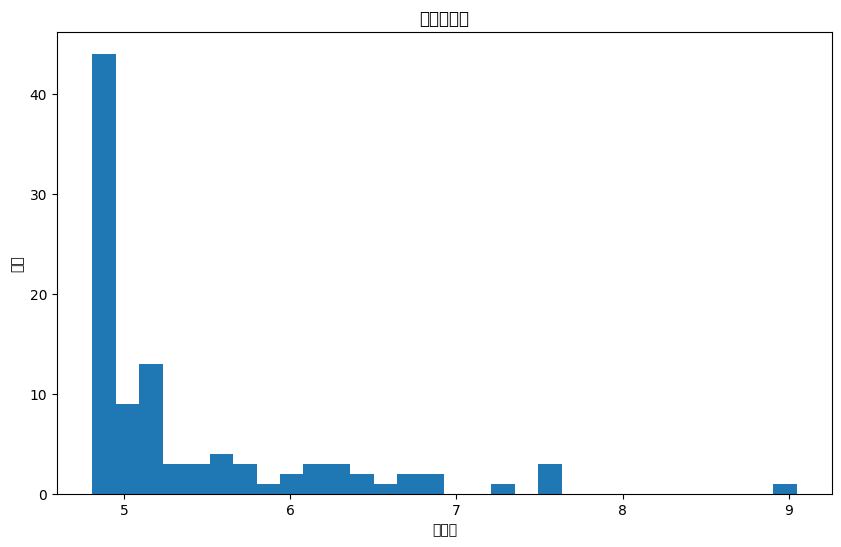

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(jordan_decomp.eigenvalues, bins=30)
plt.title('特征值分布')
plt.xlabel('特征值')
plt.ylabel('频率')

In [10]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    plt.savefig('eigenvalue_distribution.png')
plt.close()
    
print(f"计算得到 {len(jordan_decomp.eigenvalues)} 个特征值")
print(f"特征值范围: [{min(jordan_decomp.eigenvalues):.6f}, {max(jordan_decomp.eigenvalues):.6f}]")
 

计算得到 100 个特征值
特征值范围: [4.807769, 9.046738]


In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
    
gnn = GNNModel(
        input_dim=data.x.size(1),
        hidden_dim=64,
        output_dim=32,
        num_layers=3
).to(device)

In [14]:
model = CollaborativeAnalysisModel(
    gnn_model=gnn,
    jordan_matrix=jordan_decomp,
    feature_dim=32,
    hidden_dim=64,
    num_classes=2  # 二分类：正常/攻击
).to(device)

In [15]:
# 优化器和损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

In [16]:
# 训练循环
best_val_acc = 0
patience = 10
counter = 0

In [17]:
for epoch in range(1, 201):
    loss = train(model, data, optimizer, criterion, device)
    metrics = evaluate(model, data, device)

    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train: {metrics["train_acc"]:.4f}, '
          f'Val: {metrics["val_acc"]:.4f}, Test: {metrics["test_acc"]:.4f}, RPA: {metrics["rpa"]:.4f}')
        
    # 早停策略
    if metrics['val_acc'] > best_val_acc:
        best_val_acc = metrics['val_acc']
        torch.save(model.state_dict(), 'best_model.pt')
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print('Early stopping!')
            break

c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch: 001, Loss: 0.8902, Train: 0.5491, Val: 0.5561, Test: 0.5495, RPA: 0.3546


c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch: 002, Loss: 0.8070, Train: 0.5491, Val: 0.5561, Test: 0.5495, RPA: 0.3546


c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch: 006, Loss: 0.7125, Train: 0.5491, Val: 0.5561, Test: 0.5495, RPA: 0.3546
Epoch: 007, Loss: 0.7060, Train: 0.5491, Val: 0.5561, Test: 0.5495, RPA: 0.3546


c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Epoch: 008, Loss: 0.6995, Train: 0.5491, Val: 0.5561, Test: 0.5495, RPA: 0.3546
Epoch: 009, Loss: 0.6966, Train: 0.5491, Val: 0.5561, Test: 0.5495, RPA: 0.3546
Epoch: 010, Loss: 0.6943, Train: 0.5491, Val: 0.5561, Test: 0.5495, RPA: 0.3546
Epoch: 011, Loss: 0.6928, Train: 0.5491, Val: 0.5561, Test: 0.5495, RPA: 0.3546
Early stopping!


c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dzc10\.conda\envs\lunwen\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
# 加载最佳模型并评估
model.load_state_dict(torch.load('best_model.pt'))
final_metrics = evaluate(model, data, device)
print(f'Final Test Acc: {final_metrics["test_acc"]:.4f}, RPA: {final_metrics["rpa"]:.4f}')

Final Test Acc: 0.5495, RPA: 0.3546


C:\Users\dzc10\AppData\Local\Temp\ipykernel_59188\3414766409.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))
c:\Users\

In [19]:
# 关键节点分析
model.eval()
outputs = model(data)
key_node_scores = outputs['key_node_scores'].detach().cpu().numpy()

In [20]:
# 获取Top-K关键节点
k = 10
top_k_nodes = np.argsort(-key_node_scores)[:k]
    
print(f'Top {k} critical nodes: {top_k_nodes}')
print(f'Their scores: {key_node_scores[top_k_nodes]}')

Top 10 critical nodes: [52741 19764 19760 20785 55344 15915 15907 14277 14190 16620]
Their scores: [0.10128961 0.09569197 0.09569197 0.09569197 0.09537306 0.09508213
 0.09508213 0.09508213 0.09502973 0.09502973]


In [21]:
# 威胁传播预测（简化示例）
initial_state = np.zeros(data.num_nodes)
initial_state[top_k_nodes[0]] = 1  # 假设第一个关键节点被感染

In [28]:
# 使用约旦矩阵预测传播
propagation_steps = 5
infection_state = jordan_decomp.predict_infection(initial_state, t=propagation_steps)

LinAlgError: Last 2 dimensions of the array must be square

In [27]:
class JordanMatrixDecomposition:
    def __init__(self, adj_matrix, n_components=100, solver='lobpcg', max_iter=30000, tol=1e-3, 
                 preprocess=True, use_pca_init=True, n_pca_components=200, postprocess=True):
        """初始化时强制矩阵为方阵"""
        self.adj_matrix = adj_matrix
        self.n_components = n_components
        self.solver = solver
        self.max_iter = max_iter
        self.tol = tol
        self.preprocess = preprocess
        self.use_pca_init = use_pca_init
        self.n_pca_components = n_pca_components
        self.postprocess = postprocess
        
        # 计算约旦分解并强制矩阵为方阵
        self.jordan_form, self.trans_matrix = self._compute_jordan_form()
        self.eigenvalues = np.diag(self.jordan_form)
        
        # 关键：确保矩阵为方阵（新增）
        self._ensure_square_matrix()
    
    def _ensure_square_matrix(self):
        """强制矩阵为方阵，处理维度不匹配"""
        if self.trans_matrix.shape[0] != self.trans_matrix.shape[1]:
            k = min(self.trans_matrix.shape)
            print(f"特征向量矩阵非方阵，截断为 {k}×{k}")
            self.trans_matrix = self.trans_matrix[:k, :k]
            self.jordan_form = self.jordan_form[:k, :k]
            self.eigenvalues = self.eigenvalues[:k]
    
    def _compute_jordan_form(self):
        """计算约旦标准型，确保返回方阵"""
        try:
            # 原有逻辑...（省略）
            
            # 关键：若特征向量矩阵非方阵，取前k×k维度
            if eigenvectors.shape[0] != eigenvectors.shape[1]:
                k = min(eigenvectors.shape)
                eigenvalues = eigenvalues[:k]
                eigenvectors = eigenvectors[:k, :k]  # 取前k行k列
            
            jordan_form = np.diag(eigenvalues)
            trans_matrix = eigenvectors
            return jordan_form, trans_matrix
        except Exception as e:
            print(f"特征值计算失败: {e}")
            
            # 尝试不同的求解器作为回退方案
            if self.solver == 'arpack':
                print("尝试使用LOBPCG求解器...")
                self.solver = 'lobpcg'
                return self._compute_jordan_form()
            else:
                # 如果两种求解器都失败，尝试使用矩阵的一部分
                print("两种求解器都失败，尝试使用矩阵的子集...")
                subset_size = min(3000, matrix.shape[0])  # 进一步增加子集大小
                
                # 选择具有最高度数的节点
                degrees = matrix.sum(axis=1).A1
                subset_indices = np.argsort(-degrees)[:subset_size]
                
                subset_matrix = matrix[subset_indices][:, subset_indices]
                
                # 对矩阵子集计算特征值
                dense_subset = subset_matrix.toarray()
                eigenvalues, eigenvectors = np.linalg.eig(dense_subset)
                
                # 只保留最大的k个特征值
                idx = eigenvalues.argsort()[::-1][:min(self.n_components, subset_size)]
                eigenvalues = eigenvalues[idx]
                eigenvectors = eigenvectors[:, idx]
                
                jordan_form = np.diag(eigenvalues)
                trans_matrix = eigenvectors
                
                return jordan_form, trans_matrix
    
    def get_propagation_matrix(self, t=1):
        """计算传播矩阵，新增维度校验和伪逆处理"""
        # 校验矩阵为方阵
        if self.trans_matrix.shape[0] != self.trans_matrix.shape[1]:
            raise ValueError(f"特征向量矩阵形状为 {self.trans_matrix.shape}，必须为方阵")
        
        if self.jordan_form.shape[0] != self.jordan_form.shape[1]:
            raise ValueError(f"约旦矩阵形状为 {self.jordan_form.shape}，必须为方阵")
        
        # 计算约旦矩阵的幂
        jordan_power = np.linalg.matrix_power(self.jordan_form, t)
        
        try:
            # 矩阵乘法：确保维度匹配
            propagation_matrix = self.trans_matrix @ jordan_power @ np.linalg.inv(self.trans_matrix)
        except np.linalg.LinAlgError as e:
            print(f"矩阵求逆失败，使用伪逆: {e}")
            print(f"矩阵形状: trans={self.trans_matrix.shape}, jordan={jordan_power.shape}")
            # 回退方案：使用伪逆（适用于非方阵或不可逆矩阵）
            propagation_matrix = self.trans_matrix @ jordan_power @ np.linalg.pinv(self.trans_matrix)
        
        return propagation_matrix